# Feed Forward Network con PyTorch

El presente notebook corresponde a la primera tarea del segundo parcial de la materia de Inteligencia Computacional. Se entrenan tres modelos tipo red neuronal con el conjunto de datos MNIST. Se evalúa el mejor modelo con datos de prueba.

In [87]:
# Imports

import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

## Cargar conjunto de datos MNIST

Para cargar los datos se utilizó como base el ejemplo proporcionado por el profesor.

In [88]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [89]:
# Cargar conjunto de datos

x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data/mnist')

In [90]:
# Aplanar imágenes

x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)


# Convertir a tensores

x_train = torch.tensor(x_train, dtype=torch.float32)
x_val   = torch.tensor(x_val, dtype=torch.float32)
x_test  = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [91]:
# Función para mostrar una imágen del conjunto de datos

def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

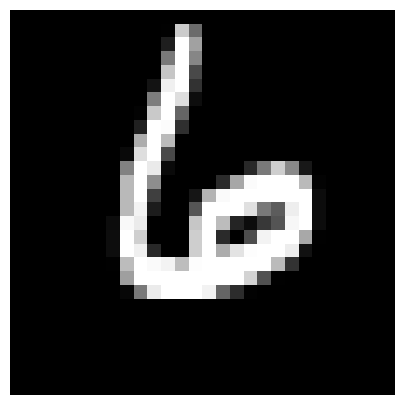

'Label: 6'

In [92]:
# Mostrar imágen aleatoria del conjunto de datos de entrenamiento

random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

In [93]:
# Implementar DataLoader

x_train = x_train / 255.0 # Normalización para agilizar entrenamiento

y_train = y_train.squeeze().long()
y_val   = y_val.squeeze().long()
y_test  = y_test.squeeze().long()

dataset = TensorDataset(x_train, y_train)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

## Definición de los 3 modelos

In [94]:
# Definir función de pérdida

loss_fn = nn.CrossEntropyLoss()

In [95]:
# Modelo 1
model_1 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=0.01)
num_epochs_1 = 20

In [96]:
# Modelo 2

model_2 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)
num_epochs_2 = 10

In [97]:
# Modelo 3

model_3 = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.0005)
num_epochs_3 = 7

## Entrenamiento de los modelos

In [98]:
# Función para evaluar pérdida y accuracy (se usó ayuda de inteligencia artificial)

def evaluate(model, X, y, loss_fn):
    model.eval()
    
    with torch.no_grad():
        outputs = model(X)
        loss = loss_fn(outputs, y)

        _, preds = torch.max(outputs, 1)
        accuracy = (preds == y).float().mean()

    return loss.item(), accuracy.item()

In [99]:
def train_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # Forward pass
    predictions = model(X_batch)
    loss = loss_fn(predictions, y_batch)

    # Backward pass
    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step()

In [100]:
# Se uso apoyo de la inteligencia artificial para usar tqdm

# Modelo 1

for epoch in range(num_epochs_1):
    model_1.train()

    for X_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs_1}"):
        train_batch(model_1, X_batch, y_batch, optimizer_1, loss_fn)
    
    # Evaluar modelo en prueba y validación e imprimir resultados
    train_loss, train_acc = evaluate(model_1, x_train, y_train, loss_fn)
    val_loss, val_acc = evaluate(model_1, x_val, y_val, loss_fn)

    print(f"Epoch {epoch+1}:")
    print(f"  Train → Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/20: 100%|██████████| 782/782 [00:02<00:00, 327.01it/s]


Epoch 1:
  Train → Loss: 0.7142, Acc: 0.8443
  Val   → Loss: 27.4083, Acc: 0.8602


Epoch 2/20: 100%|██████████| 782/782 [00:01<00:00, 458.19it/s]


Epoch 2:
  Train → Loss: 0.4683, Acc: 0.8799
  Val   → Loss: 33.4964, Acc: 0.8874


Epoch 3/20: 100%|██████████| 782/782 [00:01<00:00, 492.12it/s]


...

Epoch 18:
  Train → Loss: 0.2169, Acc: 0.9393
  Val   → Loss: 29.6881, Acc: 0.9355


Epoch 19/20: 100%|██████████| 782/782 [00:01<00:00, 527.45it/s]


Epoch 19:
  Train → Loss: 0.2121, Acc: 0.9405
  Val   → Loss: 29.3421, Acc: 0.9363


Epoch 20/20: 100%|██████████| 782/782 [00:01<00:00, 478.75it/s]


Epoch 20:
  Train → Loss: 0.2060, Acc: 0.9420
  Val   → Loss: 29.6655, Acc: 0.9364


In [101]:
# Modelo 2

for epoch in range(num_epochs_2):
    model_2.train()

    for X_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs_2}"):
        train_batch(model_2, X_batch, y_batch, optimizer_2, loss_fn)
    
    # Evaluar modelo en prueba y validación e imprimir resultados
    train_loss, train_acc = evaluate(model_2, x_train, y_train, loss_fn)
    val_loss, val_acc = evaluate(model_2, x_val, y_val, loss_fn)

    print(f"Epoch {epoch+1}:")
    print(f"  Train → Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/10: 100%|██████████| 782/782 [00:03<00:00, 244.40it/s]


Epoch 1:
  Train → Loss: 0.1474, Acc: 0.9563
  Val   → Loss: 20.1244, Acc: 0.9548


Epoch 2/10: 100%|██████████| 782/782 [00:03<00:00, 202.28it/s]


Epoch 2:
  Train → Loss: 0.0757, Acc: 0.9774
  Val   → Loss: 17.5663, Acc: 0.9667


Epoch 3/10: 100%|██████████| 782/782 [00:03<00:00, 226.04it/s]


...

Epoch 8:
  Train → Loss: 0.0133, Acc: 0.9959
  Val   → Loss: 18.1592, Acc: 0.9785


Epoch 9/10: 100%|██████████| 782/782 [00:03<00:00, 235.15it/s]


Epoch 9:
  Train → Loss: 0.0125, Acc: 0.9961
  Val   → Loss: 22.6346, Acc: 0.9780


Epoch 10/10: 100%|██████████| 782/782 [00:03<00:00, 240.91it/s]


Epoch 10:
  Train → Loss: 0.0097, Acc: 0.9969
  Val   → Loss: 20.0526, Acc: 0.9780


In [102]:
# Modelo 3

for epoch in range(num_epochs_3):
    model_3.train()
    
    for X_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs_3}"):
        train_batch(model_3, X_batch, y_batch, optimizer_3, loss_fn)
    
    # Evaluar modelo en prueba y validación e imprimir resultados
    train_loss, train_acc = evaluate(model_3, x_train, y_train, loss_fn)
    val_loss, val_acc = evaluate(model_3, x_val, y_val, loss_fn)

    print(f"Epoch {epoch+1}:")
    print(f"  Train → Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/7: 100%|██████████| 782/782 [00:06<00:00, 123.63it/s]


Epoch 1:
  Train → Loss: 0.1488, Acc: 0.9548
  Val   → Loss: 19.2707, Acc: 0.9596


Epoch 2/7: 100%|██████████| 782/782 [00:06<00:00, 116.10it/s]


Epoch 2:
  Train → Loss: 0.0853, Acc: 0.9743
  Val   → Loss: 15.3177, Acc: 0.9692


Epoch 3/7: 100%|██████████| 782/782 [00:06<00:00, 119.32it/s]


...

Epoch 5:
  Train → Loss: 0.0388, Acc: 0.9883
  Val   → Loss: 14.9667, Acc: 0.9764


Epoch 6/7: 100%|██████████| 782/782 [00:06<00:00, 123.13it/s]


Epoch 6:
  Train → Loss: 0.0247, Acc: 0.9927
  Val   → Loss: 13.9847, Acc: 0.9786


Epoch 7/7: 100%|██████████| 782/782 [00:06<00:00, 119.69it/s]


Epoch 7:
  Train → Loss: 0.0234, Acc: 0.9924
  Val   → Loss: 14.2635, Acc: 0.9776


## Evaluación de los modelos y evaluación final

In [103]:
# Evaluar los modelos finales en validación
model_1_loss, model_1_acc = evaluate(model_1, x_val, y_val, loss_fn)
model_2_loss, model_2_acc = evaluate(model_2, x_val, y_val, loss_fn)
model_3_loss, model_3_acc = evaluate(model_3, x_val, y_val, loss_fn)

print("\nResultados de Validación")
print("-" * 40)
print(f"{'Model':<10} {'Loss':<10} {'Accuracy':<10}")
print("-" * 40)

print(f"{'Model 1':<10} {model_1_loss:<10.4f} {model_1_acc:<10.4f}")
print(f"{'Model 2':<10} {model_2_loss:<10.4f} {model_2_acc:<10.4f}")
print(f"{'Model 3':<10} {model_3_loss:<10.4f} {model_3_acc:<10.4f}")

print("-" * 40)


Resultados de Validación
----------------------------------------
Model      Loss       Accuracy  
----------------------------------------
Model 1    29.6655    0.9364    
Model 2    20.0526    0.9780    
Model 3    14.2635    0.9776    
----------------------------------------


In [106]:
# Probar mejor modelo
best_model = model_3

test_loss, test_acc = evaluate(best_model, x_test, y_test, loss_fn)
print(f"Best Model Test → Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

Best Model Test → Loss: 14.7489, Acc: 0.9785


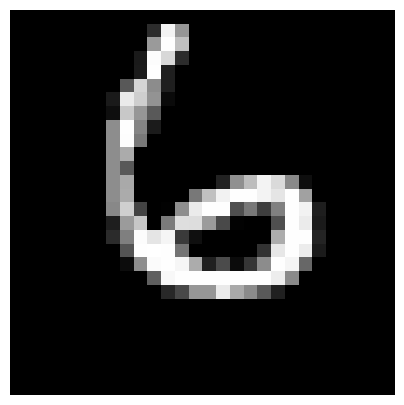

'Label: 6'

'Predicted: 6'

In [107]:
# Probar mejor modelo con imagen aleatoria

best_model.eval()

with torch.no_grad():
    outputs = best_model(x_test)
    _, y_pred = torch.max(outputs, 1)

random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].item()}", f"Predicted: {y_pred[random_idx].item()}")

## Reflexiones personales



Al realizar esta actividad pude reforzar los conocimientos vistos en clase sobre cómo utilizar Pytorch para implementar redes neuronales. Gracias a esta actividad pude comprender mejor el proceso paso a paso que se debe seguir usando esta librería, el cual es cargar el conjunto de datos, definir el o los modelos que se entrenarán, implementar el entrenamiento de los modelos, ejecutar el entrenamiento, y finalmente evaluar los modelos. Además, implementar este conjunto de datos me permitió poder aprender mejor cómo manejar imágenes como datos de entrada de los modelos. Ver la forma en que se deben de aplanar (si no es una red neuronal convolucional) y la forma en que se manejan los tensores me ayudarán para implementar modelos que tengan este tipo de entradas. Finalmente me gustaría resaltar que me sorprendió la facilidad que nos ofrece esta librería para generar redes neuronales. A pesar de esto, creo que el hecho de tener que implementar el entrenamiento es un poco inconveniente, aunque imagino que esto da mucha flexibilidad. Esto lo menciono ya que en semestres anteriores utilicé TensorFlow y si no recuerdo mal creo que esa librería permite entrenar redes neuronales de forma más automática.